# Clinical Risk Prediction – Framingham Heart Study

This project builds a logistic regression model to predict 10-year coronary heart disease (CHD) risk using clinical and demographic features.

In [3]:
import pandas as pd

df = pd.read_csv("data/framingham.csv")

df.shape

(4240, 16)

In [4]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df["TenYearCHD"].value_counts(normalize=True)

TenYearCHD
0    0.848113
1    0.151887
Name: proportion, dtype: float64

In [6]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

print(X.shape)
print(y.shape)

(4240, 15)
(4240,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3392, 15)
(848, 15)


In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8443396226415094
ROC-AUC: 0.7021918901143923


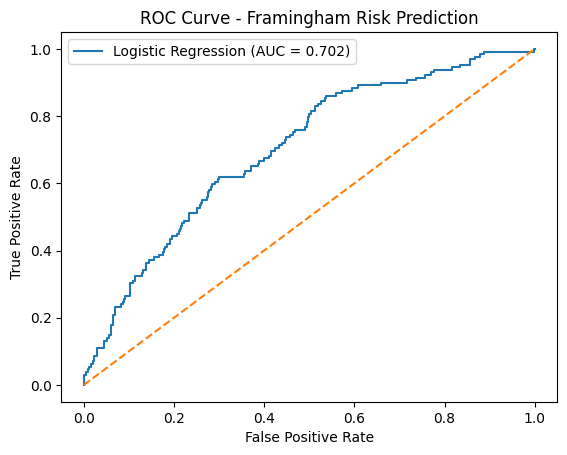

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Framingham Risk Prediction")
plt.legend()
plt.show()

In [14]:
import numpy as np

odds_ratios = np.exp(model.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Odds Ratio": odds_ratios
}).sort_values(by="Odds Ratio", ascending=False)

feature_importance

,Feature,Odds Ratio
1,age,1.780792
10,sysBP,1.353123
4,cigsPerDay,1.310853
0,male,1.245010
14,glucose,1.179470
9,totChol,1.111617
6,prevalentStroke,1.098968
7,prevalentHyp,1.072792
5,BPMeds,1.068606
8,diabetes,1.022318


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [16]:
from sklearn.metrics import roc_auc_score

y_prob = pipeline.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_prob)

0.7021918901143923

In [17]:
import numpy as np
import pandas as pd

model = pipeline.named_steps["model"]

odds_ratios = np.exp(model.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Odds Ratio": odds_ratios
}).sort_values(by="Odds Ratio", ascending=False)

feature_importance

,Feature,Odds Ratio
1,age,1.780792
10,sysBP,1.353123
4,cigsPerDay,1.310853
0,male,1.245010
14,glucose,1.179470
9,totChol,1.111617
6,prevalentStroke,1.098968
7,prevalentHyp,1.072792
5,BPMeds,1.068606
8,diabetes,1.022318
